In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


2025-02-08 12:38:48.417102: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Training data shape: (60000, 784)
Testing data shape: (10000, 784)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model():
    model = Sequential([
        Dense(512, activation="relu", input_shape=(784,)),  
        Dropout(0.2),
        Dense(256, activation="relu"),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax")  
    ])
    return model

model = build_model()
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-3), metrics=["accuracy"])

model.summary()


2025-02-08 12:39:10.279540: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               401920    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 567,434
Trainable params: 567,434
Non-trai

Epoch 1/10
469/469 [==============================] - 13s 19ms/step - loss: 2.2887 - accuracy: 0.1333 - lr: 1.0000e-06
Epoch 2/10
469/469 [==============================] - 9s 19ms/step - loss: 2.1842 - accuracy: 0.2419 - lr: 2.1544e-06
Epoch 3/10
469/469 [==============================] - 9s 19ms/step - loss: 1.9077 - accuracy: 0.4886 - lr: 4.6416e-06
Epoch 4/10
469/469 [==============================] - 9s 19ms/step - loss: 1.2135 - accuracy: 0.7196 - lr: 1.0000e-05
Epoch 5/10
469/469 [==============================] - 9s 20ms/step - loss: 0.6083 - accuracy: 0.8317 - lr: 2.1544e-05
Epoch 6/10
469/469 [==============================] - 11s 23ms/step - loss: 0.3850 - accuracy: 0.8882 - lr: 4.6416e-05
Epoch 7/10
469/469 [==============================] - 16s 33ms/step - loss: 0.2655 - accuracy: 0.9217 - lr: 1.0000e-04
Epoch 8/10
469/469 [==============================] - 14s 29ms/step - loss: 0.1867 - accuracy: 0.9449 - lr: 2.1544e-04
Epoch 9/10
469/469 [==============================] 

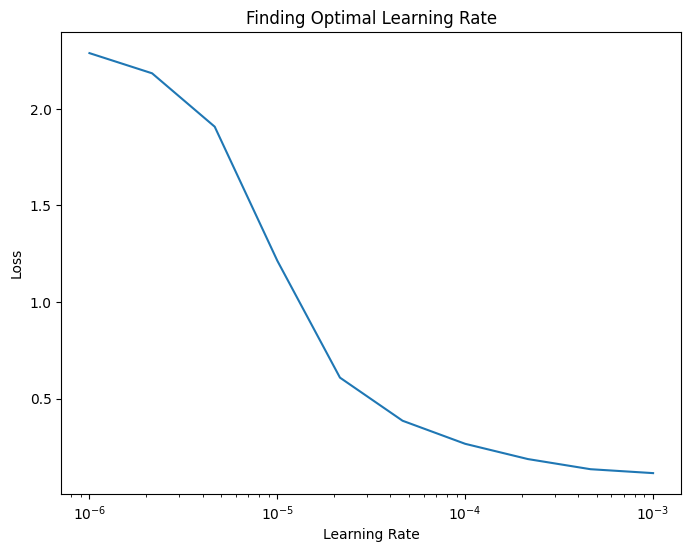

In [3]:
from tensorflow.keras.callbacks import LearningRateScheduler, History

lr_schedule = keras.callbacks.LearningRateScheduler(lambda epoch: 1e-6 * 10**(epoch / 3))
history = History()

model = build_model()
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10, batch_size=128, callbacks=[lr_schedule], verbose=1)

lrs = 1e-6 * (10 ** (np.arange(10) / 3))
losses = history.history["loss"]

plt.figure(figsize=(8, 6))
plt.semilogx(lrs, losses)
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Finding Optimal Learning Rate")
plt.show()


In [4]:
from tensorflow.keras.callbacks import TensorBoard

optimal_lr = 1e-3  

model = build_model()
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=optimal_lr), metrics=["accuracy"])

tensorboard_cb = TensorBoard(log_dir="./logs", histogram_freq=1)

history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_data=(X_test, y_test), callbacks=[tensorboard_cb])


Epoch 1/20
469/469 [==============================] - 10s 18ms/step - loss: 0.2750 - accuracy: 0.9163 - val_loss: 0.1119 - val_accuracy: 0.9664
Epoch 2/20
469/469 [==============================] - 8s 18ms/step - loss: 0.1096 - accuracy: 0.9668 - val_loss: 0.0789 - val_accuracy: 0.9753
Epoch 3/20
469/469 [==============================] - 8s 18ms/step - loss: 0.0799 - accuracy: 0.9750 - val_loss: 0.0748 - val_accuracy: 0.9767
Epoch 4/20
469/469 [==============================] - 12s 25ms/step - loss: 0.0641 - accuracy: 0.9794 - val_loss: 0.0662 - val_accuracy: 0.9793
Epoch 5/20
469/469 [==============================] - 10s 22ms/step - loss: 0.0524 - accuracy: 0.9834 - val_loss: 0.0707 - val_accuracy: 0.9790
Epoch 6/20
469/469 [==============================] - 11s 23ms/step - loss: 0.0451 - accuracy: 0.9852 - val_loss: 0.0655 - val_accuracy: 0.9801
Epoch 7/20
469/469 [==============================] - 15s 31ms/step - loss: 0.0412 - accuracy: 0.9867 - val_loss: 0.0587 - val_accuracy: 0

In [5]:

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}") 


313/313 [==============================] - 1s 4ms/step - loss: 0.0654 - accuracy: 0.9839
Test Accuracy: 0.9839


In [7]:
import os
print(os.listdir("./logs"))

['train', 'validation']


In [44]:
# Run this in a terminal or Jupyter cell
%load_ext tensorboard
%tensorboard --logdir=./logs


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 63467), started 1 day, 2:01:24 ago. (Use '!kill 63467' to kill it.)

2.

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


In [19]:

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)


Training set shape: (60000, 784)
Test set shape: (10000, 784)


In [20]:
def create_model(activation_function):
    model = keras.Sequential()
    
    model.add(layers.Input(shape=(784,)))
    
    for _ in range(100):
        model.add(layers.Dense(64, activation=activation_function))

    model.add(layers.Dense(10, activation="softmax"))

    model.compile(optimizer="adam", 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"])
    
    return model


In [21]:
activations = ["sigmoid", "relu", "elu", "selu"]
history_dict = {}

for activation in activations:
    print(f"\nTraining model with {activation} activation...\n")
    model = create_model(activation)
    
    history = model.fit(x_train, y_train, epochs=5, batch_size=256, validation_data=(x_test, y_test), verbose=1)
    history_dict[activation] = history



Training model with sigmoid activation...

Epoch 1/5
235/235 [==============================] - 46s 80ms/step - loss: 2.3071 - accuracy: 0.0997 - val_loss: 2.3047 - val_accuracy: 0.1000
Epoch 2/5
235/235 [==============================] - 17s 71ms/step - loss: 2.3052 - accuracy: 0.0989 - val_loss: 2.3048 - val_accuracy: 0.1000
Epoch 3/5
235/235 [==============================] - 20s 86ms/step - loss: 2.3052 - accuracy: 0.0999 - val_loss: 2.3050 - val_accuracy: 0.1000
Epoch 4/5
235/235 [==============================] - 20s 87ms/step - loss: 2.3049 - accuracy: 0.1004 - val_loss: 2.3054 - val_accuracy: 0.1000
Epoch 5/5
235/235 [==============================] - 20s 84ms/step - loss: 2.3044 - accuracy: 0.0985 - val_loss: 2.3054 - val_accuracy: 0.1000

Training model with relu activation...

Epoch 1/5
235/235 [==============================] - 49s 74ms/step - loss: 2.3027 - accuracy: 0.0984 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 2/5
235/235 [==============================] - 16s 

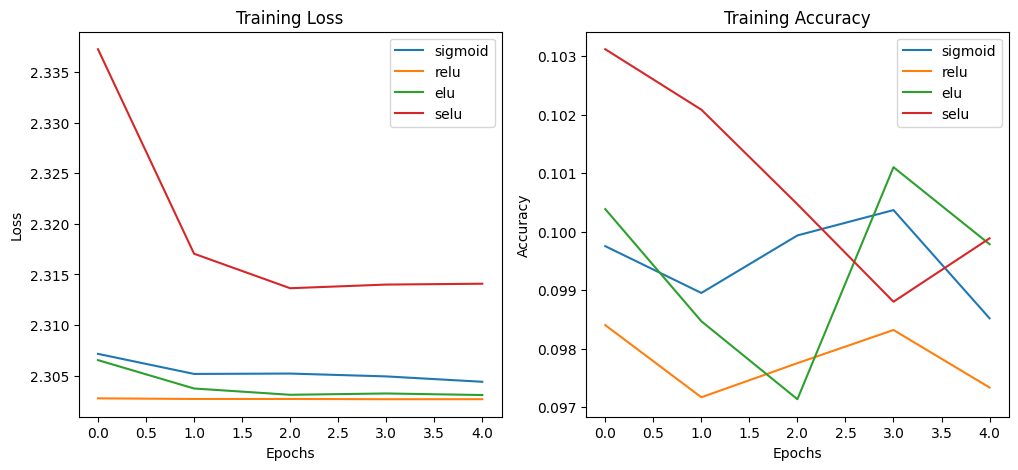

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for activation in activations:
    plt.plot(history_dict[activation].history['loss'], label=f"{activation}")

plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
for activation in activations:
    plt.plot(history_dict[activation].history['accuracy'], label=f"{activation}")

plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


3.

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, ELU, Flatten, Input
from tensorflow.keras.optimizers import Nadam, SGD, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.initializers import HeNormal


In [25]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


170498071/170498071 [==============================] - 45s 0us/step


In [30]:
from tensorflow.keras import optimizers

model = build_model()

model.compile(optimizer=optimizers.Adam(), 
              loss='categorical_crossentropy',  
              metrics=['accuracy'])  
model.summary()
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])


Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 2304)              0         
                                                                 
 dense_843 (Dense)           (None, 128)             

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, ELU, Input, Flatten
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.callbacks import EarlyStopping

def build_model_with_batch_norm():
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))  
    model.add(Flatten())  

  
    for _ in range(20):
        model.add(Dense(100, kernel_initializer=HeNormal()))
        model.add(BatchNormalization()) 
        model.add(ELU())

    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer=Nadam(), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_bn = build_model_with_batch_norm()
history_bn = model_bn.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])


Epoch 1/50
782/782 [==============================] - 72s 41ms/step - loss: 1.7718 - accuracy: 0.3662 - val_loss: 1.8517 - val_accuracy: 0.3383
Epoch 2/50
782/782 [==============================] - 26s 34ms/step - loss: 1.5881 - accuracy: 0.4352 - val_loss: 1.6387 - val_accuracy: 0.4199
Epoch 3/50
782/782 [==============================] - 30s 39ms/step - loss: 1.5167 - accuracy: 0.4602 - val_loss: 1.8826 - val_accuracy: 0.3821
Epoch 4/50
782/782 [==============================] - 26s 33ms/step - loss: 1.4579 - accuracy: 0.4828 - val_loss: 1.5733 - val_accuracy: 0.4425
Epoch 5/50
782/782 [==============================] - 25s 32ms/step - loss: 1.4131 - accuracy: 0.4988 - val_loss: 1.6778 - val_accuracy: 0.4211
Epoch 6/50
782/782 [==============================] - 24s 31ms/step - loss: 1.3743 - accuracy: 0.5122 - val_loss: 1.6868 - val_accuracy: 0.4291
Epoch 7/50
782/782 [==============================] - 25s 32ms/step - loss: 1.3362 - accuracy: 0.5263 - val_loss: 1.6356 - val_accuracy:

In [33]:
model_sgd = build_model()
model_sgd.compile(optimizer=SGD(), loss='categorical_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])


Epoch 1/50
782/782 [==============================] - 83s 98ms/step - loss: 2.0977 - accuracy: 0.2356 - val_loss: 1.9265 - val_accuracy: 0.2979
Epoch 2/50
782/782 [==============================] - 64s 82ms/step - loss: 1.8142 - accuracy: 0.3583 - val_loss: 1.9502 - val_accuracy: 0.2810
Epoch 3/50
782/782 [==============================] - 64s 82ms/step - loss: 1.6182 - accuracy: 0.4231 - val_loss: 1.6064 - val_accuracy: 0.4308
Epoch 4/50
782/782 [==============================] - 72s 92ms/step - loss: 1.4884 - accuracy: 0.4703 - val_loss: 1.4927 - val_accuracy: 0.4578
Epoch 5/50
782/782 [==============================] - 65s 83ms/step - loss: 1.4122 - accuracy: 0.4982 - val_loss: 1.4992 - val_accuracy: 0.4818
Epoch 6/50
782/782 [==============================] - 65s 83ms/step - loss: 1.3559 - accuracy: 0.5203 - val_loss: 1.5595 - val_accuracy: 0.4393
Epoch 7/50
782/782 [==============================] - 67s 85ms/step - loss: 1.3047 - accuracy: 0.5392 - val_loss: 2.2672 - val_accuracy:

In [34]:
model_momentum = build_model()
model_momentum.compile(optimizer=SGD(momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])
history_momentum = model_momentum.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])


Epoch 1/50
782/782 [==============================] - 97s 118ms/step - loss: 1.6930 - accuracy: 0.3834 - val_loss: 1.4610 - val_accuracy: 0.4761
Epoch 2/50
782/782 [==============================] - 60s 76ms/step - loss: 1.2508 - accuracy: 0.5568 - val_loss: 1.1474 - val_accuracy: 0.5956
Epoch 3/50
782/782 [==============================] - 74s 95ms/step - loss: 1.0632 - accuracy: 0.6290 - val_loss: 1.0288 - val_accuracy: 0.6374
Epoch 4/50
782/782 [==============================] - 74s 95ms/step - loss: 0.9350 - accuracy: 0.6731 - val_loss: 0.9912 - val_accuracy: 0.6574
Epoch 5/50
782/782 [==============================] - 73s 93ms/step - loss: 0.8395 - accuracy: 0.7069 - val_loss: 0.9827 - val_accuracy: 0.6642
Epoch 6/50
782/782 [==============================] - 62s 79ms/step - loss: 0.7523 - accuracy: 0.7389 - val_loss: 0.9097 - val_accuracy: 0.6874
Epoch 7/50
782/782 [==============================] - 73s 94ms/step - loss: 0.6704 - accuracy: 0.7665 - val_loss: 0.9415 - val_accuracy

In [35]:
model_nag = build_model()
model_nag.compile(optimizer=SGD(momentum=0.9, nesterov=True), loss='categorical_crossentropy', metrics=['accuracy'])
history_nag = model_nag.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])


Epoch 1/50
782/782 [==============================] - 84s 102ms/step - loss: 1.6192 - accuracy: 0.4158 - val_loss: 1.4054 - val_accuracy: 0.4992
Epoch 2/50
782/782 [==============================] - 71s 91ms/step - loss: 1.1930 - accuracy: 0.5799 - val_loss: 1.1191 - val_accuracy: 0.6091
Epoch 3/50
782/782 [==============================] - 74s 95ms/step - loss: 1.0140 - accuracy: 0.6449 - val_loss: 1.0404 - val_accuracy: 0.6406
Epoch 4/50
782/782 [==============================] - 97s 124ms/step - loss: 0.8918 - accuracy: 0.6908 - val_loss: 1.0599 - val_accuracy: 0.6377
Epoch 5/50
782/782 [==============================] - 74s 95ms/step - loss: 0.7940 - accuracy: 0.7246 - val_loss: 0.9447 - val_accuracy: 0.6794
Epoch 6/50
782/782 [==============================] - 77s 98ms/step - loss: 0.7007 - accuracy: 0.7544 - val_loss: 0.9099 - val_accuracy: 0.6954
Epoch 7/50
782/782 [==============================] - 74s 95ms/step - loss: 0.6216 - accuracy: 0.7828 - val_loss: 0.9535 - val_accurac

In [43]:
from tensorflow.keras.optimizers import Adagrad

model_adagrad = build_model()

model_adagrad.compile(optimizer=Adagrad(), loss='categorical_crossentropy', metrics=['accuracy'])

history_adagrad = model_adagrad.fit(
    x_train, y_train,
    epochs=50, batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping]
)



Epoch 1/50
782/782 [==============================] - 82s 99ms/step - loss: 2.2573 - accuracy: 0.1743 - val_loss: 2.1988 - val_accuracy: 0.2135
Epoch 2/50
782/782 [==============================] - 66s 84ms/step - loss: 2.1184 - accuracy: 0.2462 - val_loss: 2.0521 - val_accuracy: 0.2663
Epoch 3/50
782/782 [==============================] - 70s 89ms/step - loss: 1.9981 - accuracy: 0.2907 - val_loss: 1.9615 - val_accuracy: 0.3065
Epoch 4/50
782/782 [==============================] - 68s 87ms/step - loss: 1.9328 - accuracy: 0.3174 - val_loss: 1.9092 - val_accuracy: 0.3304
Epoch 5/50
782/782 [==============================] - 74s 94ms/step - loss: 1.8846 - accuracy: 0.3363 - val_loss: 1.8619 - val_accuracy: 0.3457
Epoch 6/50
782/782 [==============================] - 70s 89ms/step - loss: 1.8428 - accuracy: 0.3539 - val_loss: 1.8236 - val_accuracy: 0.3689
Epoch 7/50
782/782 [==============================] - 71s 91ms/step - loss: 1.8040 - accuracy: 0.3702 - val_loss: 1.7903 - val_accuracy:

In [38]:
model_rmsprop = build_model()
model_rmsprop.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])
history_rmsprop = model_rmsprop.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])


Epoch 1/50
782/782 [==============================] - 74s 90ms/step - loss: 1.5906 - accuracy: 0.4302 - val_loss: 1.3241 - val_accuracy: 0.5192
Epoch 2/50
782/782 [==============================] - 69s 89ms/step - loss: 1.1843 - accuracy: 0.5862 - val_loss: 1.2360 - val_accuracy: 0.5671
Epoch 3/50
782/782 [==============================] - 72s 92ms/step - loss: 1.0132 - accuracy: 0.6482 - val_loss: 1.1150 - val_accuracy: 0.6088
Epoch 4/50
782/782 [==============================] - 78s 100ms/step - loss: 0.8903 - accuracy: 0.6913 - val_loss: 0.9809 - val_accuracy: 0.6620
Epoch 5/50
782/782 [==============================] - 94s 120ms/step - loss: 0.7900 - accuracy: 0.7277 - val_loss: 0.9805 - val_accuracy: 0.6681
Epoch 6/50
782/782 [==============================] - 82s 105ms/step - loss: 0.7023 - accuracy: 0.7588 - val_loss: 0.9513 - val_accuracy: 0.6827
Epoch 7/50
782/782 [==============================] - 85s 109ms/step - loss: 0.6196 - accuracy: 0.7857 - val_loss: 1.0140 - val_accur

In [39]:
model_adam = build_model()
model_adam.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])


Epoch 1/50
782/782 [==============================] - 76s 89ms/step - loss: 1.4445 - accuracy: 0.4833 - val_loss: 1.1949 - val_accuracy: 0.5829
Epoch 2/50
782/782 [==============================] - 66s 84ms/step - loss: 1.1052 - accuracy: 0.6137 - val_loss: 1.0378 - val_accuracy: 0.6429
Epoch 3/50
782/782 [==============================] - 69s 88ms/step - loss: 0.9640 - accuracy: 0.6654 - val_loss: 0.9750 - val_accuracy: 0.6633
Epoch 4/50
782/782 [==============================] - 74s 95ms/step - loss: 0.8642 - accuracy: 0.6997 - val_loss: 0.9377 - val_accuracy: 0.6804
Epoch 5/50
782/782 [==============================] - 70s 90ms/step - loss: 0.7843 - accuracy: 0.7285 - val_loss: 0.9333 - val_accuracy: 0.6875
Epoch 6/50
782/782 [==============================] - 67s 85ms/step - loss: 0.7148 - accuracy: 0.7523 - val_loss: 0.8596 - val_accuracy: 0.7099
Epoch 7/50
782/782 [==============================] - 69s 89ms/step - loss: 0.6521 - accuracy: 0.7741 - val_loss: 0.8771 - val_accuracy:

In [40]:
model_nadam = build_model()
model_nadam.compile(optimizer=Nadam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_nadam = model_nadam.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])


Epoch 1/50
782/782 [==============================] - 89s 100ms/step - loss: 1.4308 - accuracy: 0.4878 - val_loss: 1.2777 - val_accuracy: 0.5503
Epoch 2/50
782/782 [==============================] - 72s 92ms/step - loss: 1.0886 - accuracy: 0.6183 - val_loss: 1.0557 - val_accuracy: 0.6270
Epoch 3/50
782/782 [==============================] - 77s 98ms/step - loss: 0.9524 - accuracy: 0.6688 - val_loss: 1.0435 - val_accuracy: 0.6323
Epoch 4/50
782/782 [==============================] - 76s 98ms/step - loss: 0.8556 - accuracy: 0.7038 - val_loss: 0.9332 - val_accuracy: 0.6760
Epoch 5/50
782/782 [==============================] - 60s 76ms/step - loss: 0.7776 - accuracy: 0.7292 - val_loss: 0.9129 - val_accuracy: 0.6884
Epoch 6/50
782/782 [==============================] - 65s 84ms/step - loss: 0.7075 - accuracy: 0.7530 - val_loss: 0.8743 - val_accuracy: 0.7050
Epoch 7/50
782/782 [==============================] - 77s 98ms/step - loss: 0.6421 - accuracy: 0.7762 - val_loss: 0.8916 - val_accuracy

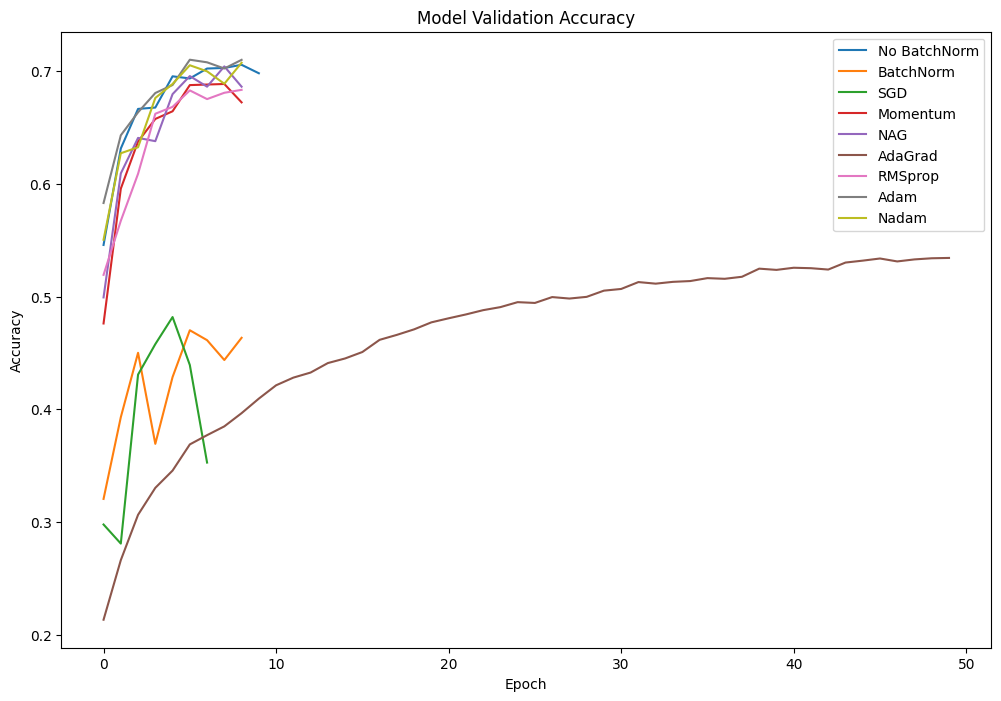

In [45]:
import matplotlib.pyplot as plt

def plot_history(histories, labels):
    plt.figure(figsize=(12, 8))
    for history, label in zip(histories, labels):
        plt.plot(history.history['val_accuracy'], label=label)
    plt.title('Model Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

histories = [history, history_bn, history_sgd, history_momentum, history_nag, history_adagrad, history_rmsprop, history_adam, history_nadam]
labels = ['No BatchNorm', 'BatchNorm', 'SGD', 'Momentum', 'NAG', 'AdaGrad', 'RMSprop', 'Adam', 'Nadam']
plot_history(histories, labels)
